In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [8]:
# A made-up samples
X_train = np.array([[18, 10, 0],
                    [16, 7, 1],
                    [26, 6, 0],
                    [14, 10, 1],
                    [11, 10, 1],
                    [21, 5, 0],
                    [13, 10, 0],
                    [10, 8, 0],
                    [10, 10, 0],
                    [9, 10, 1],
                    [9, 8, 1],
                    [17, 5, 0],
                    [16, 6, 0],
                    [16, 4, 0],
                    [40, 10, 0],
                    [35, 9, 1],
                    ],
                   )

X_train = np.tile(X_train, (1000, 1))
y_train = np.array([50000, 12000, 23000, 45000, 68000, 20000, 88000,
                   90000, 150000, 130000, 85000, 15000, 23000, 11000, 35000, 15000]) / 10000
y_train = np.tile(y_train, 1000)

In [9]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(3,)),
    tf.keras.layers.Dense(units = 25, activation='relu'),
    tf.keras.layers.Dense(units = 1, activation='linear')
])

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 25)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126 (504.00 B)

 Trainable params: 126 (504.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss=tf.keras.losses.MeanSquaredError(), optimizer='adam')
model.fit(X_train, y_train, epochs=200)

Epoch 1/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - loss: 8.0589 
Epoch 2/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 355us/step - loss: 2.9521
Epoch 3/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - loss: 1.7760
Epoch 4/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step - loss: 1.0405
Epoch 5/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - loss: 0.7351
Epoch 6/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - loss: 0.6519
Epoch 7/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - loss: 0.6318
Epoch 8/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - loss: 0.6169
Epoch 9/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 0.6040
Epoch 10/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 0.5939
Epoch 11/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step - loss: 0.5868
Epoch 12/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step - loss: 0.5760
Epoch 13/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - loss: 0.5697
Epoch 14/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 0.5574
Epoch 15/200
5

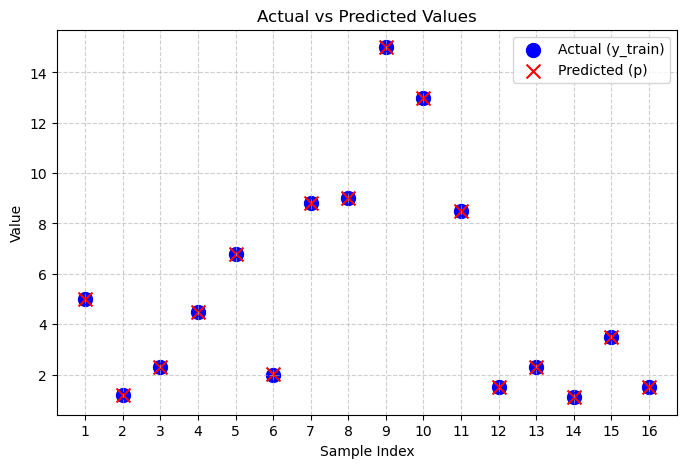

In [12]:
predictions = []
actual_values = []

actual_sample_size = 16

for m in range(len(X_train[0:actual_sample_size,])):
    p = model.predict(X_train[m].reshape(1, -1), verbose=0)

    predictions.append(p[0][0])
    actual_values.append(y_train[m])

plt.figure(figsize=(8, 5))
sample_indices = range(1, actual_sample_size + 1)

plt.scatter(sample_indices, actual_values, color='blue',
            label='Actual (y_train)', marker='o', s=100)
plt.scatter(sample_indices, predictions, color='red',
            label='Predicted (p)', marker='x', s=100)

plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.xticks(sample_indices)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)